# **Homework 2: Image segmentation without user input**

## Overview
This homework has two parts.

The first part of this homework is to implement [Grad-CAM](https://arxiv.org/pdf/1610.02391) – a method for producing saliency maps (heatmaps of regions that are most relevant to a model) that uses both activations and gradients of the feature maps of a convolutional layer. Feature maps of deeper convolutional layers represent more high-level features, while preserving rough spatial structure, which makes them a good candidate for explaining a model's output.

The second part of this homework is to use SAM for image segmentation without user input.
SAM [(Segment Anything Model v1)](https://arxiv.org/pdf/2304.02643) is a popular family of open-weight models for image segmentation (based on the vision transformer ViT and CLIP).
The model takes as input an image to be segmented and additionaly bounding boxes, point coordinates etc. clarifying the object of interest to be segmented. It can output many proposed segmentations of many objects on one image. Your task will be to find appropriate point coordinates automatically, so that SAM can be used with just an image input to segment particular objects.

---

## Dataset

You will use a small custom dataset based on [CIFAR10](https://en.wikipedia.org/wiki/CIFAR-10), but containing images with one of five objects (circle, square, diamond, triangle, star), with ground-truth segmentations of that object.

---

## GradCAM task

For the first task:
* Read the original [Grad-CAM](https://arxiv.org/pdf/1610.02391) paper.
* Implement it, without using non-standard packages (the only imports allowed are built-ins, torch, torchvision, numpy, scipy, and helpers like cv2, PIL, tqdm, matplotlib).
* The result should be a class named `GradCAM` with methods:
    * `def __init__(model: nn.Module, target_layers=Iterable[nn.Module])`
    * `def __call__(self, image: Tensor, targets: Iterable[int] | None = None) -> np.ndarray` where
        * `image` is an input to `model` (a normalized batch of shape `B,C,H,W`).
        * `targets` is an iterable of target classes that we want to segment; if None is given, use the top class predicted by the model.
        * The result is a numpy array of shape (B, H, W) containing the GradCam heatmap, with `min..max` values rescaled to `0..1` (independently for each image in the batch and each `target_layers`). If more than one `target_layers` was given, return the average of the resulting heatmaps.      
    * Feel free to add optional/default arguments and additional methods.
* Check your implementation by running the code under the `GradCAM results` header.

Tip: you may find it particularly useful to use: [nn.Module.register_full_backward_hook](https://docs.pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook).


## Segmentation task

For the second part, SAM is given as a black-box. You must design a pipeline that takes only an image and outputs a segmentation of the circle/square/diamond/triangle/star shape. The input to SAM should be the image and coordinates of point(s) that are likely to be inside ("foreground") or likely to be outside ("background") of the shape. **The coordinates must be the output of the previous step of the pipeline. They cannot be provided directly by user.**

* Think of a way to find appropriate points. Try two different approaches:
    1. at least one foreground point, without background points.
    2. at least one foreground point and at least one background point.
* Implement both approches as subclasses of `BasicSamPipeline`, overriding the `__call__` method (preserving the signature).
* Evaluate your generated point(s) and report the following metrics:
    * *hit rate*: how often they fall inside the ground-truth mask;
    * *distance*: distance from the center of mass of the ground-truth mask
        (the average coordinate of True pixels in the mask).
* Evaluate your overall pipeline and report the following metric:
    * *Intersection over Union (IoU)* of the predicted and ground-truth masks, averaged over all images in the dataset.


**Important**: This task is not about finding the pipeline with best hyperparameters; we expect an IoU of at least `65%`, but achieving results higher than that will not affect the grade for the assignment.

**Important**: Do not train or fine-tune your own models, only use the ones provided (the classifier and SAM).

---

## Deliverables

On [Moodle](https://moodle.mimuw.edu.pl/mod/assign/view.php?id=159965), submit a .zip archive with:

1. **Notebook** (`.ipynb`):
    * It should contain:
        * The GradCAM implementation.
        * The two `BasicSamPipeline` subclasses.
        * Evaluations with computations of all reported metrics.
    * It should be possible to execute the whole notebook start-to-end without human intervention.
    * Such an execution should take less than 30 minutes on a Colab GPU.
    * Do not modify (but *do* execute) cells under headers marked as `[do not modify]`. If you wish to extend them (e.g. to check more GradCAM results), you may do so **under a new header**.

2. **Report (1-2 pages, PDF)** including:
   * An examplary visualization of the output of the Grad-CAM
   * A concise description of each approach for the SAM pipelines (1-3 sentences each).
   * A presentation of all metrics.
   * Discussion (up to 5 sentences) on potential areas for improvements.

3. **README.md**:
   * Link to Colab version of the notebook for fast replication.



## Grading

1. Implementation correctness of Grad-CAM:  30%
2. Implementation correctness of the multistage pipeline and evaluations: 50%
3. Report & analysis: 20%

Please take care of readability, clear structure in particular (headers in notebooks, modular code).
This will be considered within each grading component.



# 0. Preliminaries

## Imports

In [1]:
!pip install torch torchvision matplotlib opencv-python-headless numpy segment-anything

In [2]:
import os
import random
from collections.abc import Callable, Iterable
from pathlib import Path
from typing import Any, Final, Literal, TypedDict

import cv2
import matplotlib.pyplot as plt
import numpy as np
import PIL.Image
import scipy.ndimage
import torch
import torch.nn.functional as F
import torchvision.models
from torch import Tensor, nn, optim
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import CIFAR10
from torchvision.transforms import v2
from tqdm import tqdm

In [3]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(42)

## Dataset [do not modify]

CIFAR-10 download takes 170 MiB.

In [4]:
%%bash --no-raise-error
mkdir -p data/
wget -nc -q -O data/synthetic_shapes.zip https://www.mimuw.edu.pl/~mwrochna/upload/synthetic_shapes.zip
unzip -d data/ data/synthetic_shapes.zip &> /dev/null

In [5]:
class SyntheticData[T](Dataset):
    """A small synthetic segmentation dataset.

    It is a sequence dataset of 5000 tuples (image, class, mask), where:
    - image: before transformation, an RGB PIL Image.
    - class: int 0..4, the label index.
    - mask:  numpy array of dtype=bool, shape (H, W), same size as image.
    """

    CLASSES: Final[tuple[str, ...]] = ("circle", "square", "triangle", "star", "diamond")

    def __init__(
        self,
        path: Path,
        split: Literal["train", "val", "test"],
        transform: Callable[[PIL.Image.Image], T],
    ) -> None:
        self.path = path
        self.transform = transform
        self.split = split

        self.class_to_idx = {class_name: i for i, class_name in enumerate(self.CLASSES)}

        images = sorted((self.path / "images" / self.split).glob("*.png"))
        masks = sorted((self.path / "masks" / self.split).glob("*.png"))
        labels = sorted((self.path / "labels" / self.split).glob("*.txt"))

        assert images, f"No images found in {self.path / 'images' / self.split}"
        assert len(images) == len(masks) == len(labels), (
            "Number of images, masks, and labels must be the same"
        )
        assert [p.stem for p in images] == [p.stem for p in masks] == [p.stem for p in labels], (
            "Image/mask/label filename mismatch."
        )
        self.image_names = [p.stem for p in images]

    def __len__(self) -> int:
        return len(self.image_names)

    def __getitem__(self, idx) -> tuple[T, int, np.ndarray]:
        name = self.image_names[idx]
        img_path = self.path / "images" / self.split / f"{name}.png"
        mask_path = self.path / "masks" / self.split / f"{name}.png"
        label_path = self.path / "labels" / self.split / f"{name}.txt"

        img = PIL.Image.open(img_path).convert("RGB")
        mask = np.array(PIL.Image.open(mask_path), dtype=bool)
        label = self.class_to_idx[label_path.read_text().strip()]

        img_transformed: T = self.transform(img)

        return img_transformed, label, mask


def show_image_row(
    image_dict: dict[str, PIL.Image.Image | np.ndarray | Tensor], size: float = 3.0
) -> None:
    n = len(image_dict)
    _, axs = plt.subplots(1, n, figsize=(size * n, size), constrained_layout=True, squeeze=True)
    if n == 1:
        axs = [axs]
    for ax, (title, img) in zip(axs, image_dict.items(), strict=True):
        ax.imshow(img)
        ax.set_title(title)
        ax.axis("off")
    plt.show()

train dataset size: 3500
val dataset size: 1000
test dataset size: 500


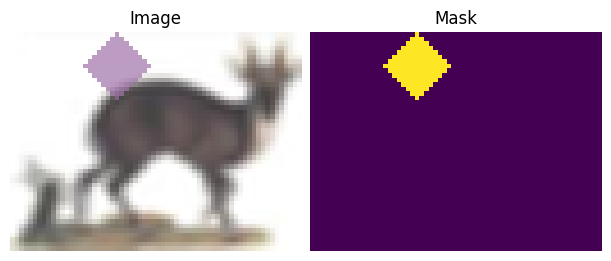

Label: 4 (diamond)


In [6]:
dataset_path = Path("./data/synthetic_shapes")


def example_from_dataset(idx: int = 3):
    for split in ("train", "val", "test"):
        dataset = SyntheticData(dataset_path, split=split, transform=lambda x: x)
        print(f"{split} dataset size: {len(dataset)}")

    img, label, mask = dataset[idx]
    show_image_row({"Image": img, "Mask": mask})
    print(f"Label: {label} ({SyntheticData.CLASSES[label]})")


example_from_dataset()

## Training a classifier [do not modify]

In [7]:
def train(
    model: nn.Module,
    train_loader: torch.utils.data.DataLoader,
    val_loader: torch.utils.data.DataLoader,
    test_loader: torch.utils.data.DataLoader,
    epochs: int = 5,
    **optimizer_kwargs: Any,
) -> None:
    print(f"🚀 Training CNN for {epochs} epochs...")
    optimizer = optim.AdamW(model.parameters(), **optimizer_kwargs)

    for epoch in range(epochs):
        _train_epoch(model, train_loader, optimizer, desc=f"Epoch {epoch + 1}/{epochs} training  ")
        val_metrics = evaluate(model, val_loader, desc=f"Epoch {epoch + 1}/{epochs} validation")
        print(
            f"Epoch {epoch + 1}/{epochs} — "
            + f"val loss: {val_metrics['loss']:.3f}, val acc: {val_metrics['accuracy']:.1%}"
        )

    test_metrics = evaluate(model, test_loader, desc="Test Evaluation")
    print(
        "✅ Model training complete: "
        + f"Test loss: {test_metrics['loss']:.3f}, test acc: {test_metrics['accuracy']:.1%}"
    )


def _train_epoch(
    model: nn.Module,
    dataloader: torch.utils.data.DataLoader,
    optimizer: optim.Optimizer,
    desc: str,
) -> dict[str, float]:
    model.train()
    device = next(model.parameters()).device
    total_loss = 0
    total_correct = 0
    total_samples = 0
    progress_bar = tqdm(dataloader, desc=desc)
    for imgs, labels, _ in progress_bar:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = nn.CrossEntropyLoss()(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

        _, predicted = torch.max(outputs.data, dim=1)
        total_samples += labels.shape[0]
        total_correct += (predicted == labels).sum().item()

        progress_bar.set_postfix(
            train_loss=f"{total_loss / (total_samples / labels.shape[0]):.3f}",
            train_acc=f"{total_correct / total_samples:.1%}",
        )

    return {"loss": total_loss / len(dataloader), "accuracy": total_correct / total_samples}


def evaluate(
    model: nn.Module, dataloader: torch.utils.data.DataLoader, desc: str
) -> dict[str, float]:
    model.eval()
    device = next(model.parameters()).device
    total_loss = 0
    total_correct = 0
    total_samples = 0
    with torch.no_grad():
        for imgs, labels, _mask in tqdm(dataloader, desc=desc):
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = nn.CrossEntropyLoss()(outputs, labels)
            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, dim=1)
            total_samples += labels.shape[0]
            total_correct += (predicted == labels).sum().item()

    return {"loss": total_loss / len(dataloader), "accuracy": total_correct / total_samples}


class DataloaderArgs(TypedDict, total=False):
    batch_size: int
    shuffle: bool
    num_workers: int
    pin_memory: bool

In [8]:
device = torch.accelerator.current_accelerator(check_available=True) or torch.device("cpu")
use_accel = device != torch.device("cpu")
print(use_accel, device)

True cuda


In [9]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)
transform = v2.Compose(
    [
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]
)
inverse_transform = v2.Compose(
    [
        v2.Normalize(
            [-m / s for m, s in zip(IMAGENET_MEAN, IMAGENET_STD, strict=True)],
            [1 / s for s in IMAGENET_STD],
        ),
        v2.ToPILImage(),
    ]
)

train_dataset = SyntheticData(dataset_path, transform=transform, split="train")
val_dataset = SyntheticData(dataset_path, transform=transform, split="val")
test_dataset = SyntheticData(dataset_path, transform=transform, split="test")

train_kwargs: DataloaderArgs = {
    "batch_size": 128,
    "num_workers": 2,
    "shuffle": True,
    "pin_memory": use_accel,
}
val_kwargs: DataloaderArgs = {"batch_size": 500, "num_workers": 2, "pin_memory": use_accel}
test_kwargs: DataloaderArgs = val_kwargs

train_loader = DataLoader(train_dataset, **train_kwargs)
val_loader = DataLoader(val_dataset, **val_kwargs)
test_loader = DataLoader(test_dataset, **test_kwargs)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")
print("✅ DataLoaders created for train, validation, and test sets.")

Train dataset size: 3500
Validation dataset size: 1000
Test dataset size: 500
✅ DataLoaders created for train, validation, and test sets.


In [10]:
checkpoint_path = Path("./model_checkpoint.pth")

model = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, len(SyntheticData.CLASSES))
model = model.to(device)

if not checkpoint_path.exists():
    train(model, train_loader, val_loader, test_loader, epochs=5, lr=2e-3, weight_decay=0.05)
    torch.save(model.state_dict(), checkpoint_path)
else:
    model.load_state_dict(torch.load(checkpoint_path, map_location=device, weights_only=True))
    metrics = evaluate(model, test_loader, desc="Test Evaluation")
    print()
    print(
        "✅ Model loaded from checkpoint: "
        + f"Test loss: {metrics['loss']:.3f}, test acc: {metrics['accuracy']:.1%}"
    )

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 101MB/s]


🚀 Training CNN for 5 epochs...


Epoch 1/5 validation: 100%|██████████| 2/2 [00:00<00:00,  2.22it/s]


Epoch 1/5 — val loss: 1.351, val acc: 51.7%


...

Epoch 4/5 — val loss: 0.546, val acc: 83.7%


Epoch 5/5 validation: 100%|██████████| 2/2 [00:01<00:00,  1.48it/s]


Epoch 5/5 — val loss: 0.533, val acc: 86.4%


Test Evaluation: 100%|██████████| 1/1 [00:00<00:00,  1.26it/s]

✅ Model training complete: Test loss: 0.407, test acc: 89.6%


# 1. GradCAM

## GradCAM implementation (add your code)

In [11]:
class GradCAM:
    """
    Pure PyTorch implementation of Grad-CAM.

    Usage:
        grad_cam = GradCAM(model=model, target_layers=[layer1, layer2])
        grayscale_cam = grad_cam(input_tensor, targets=[class_id])
    """

    def __init__(
        self,
        model: nn.Module,
        target_layers: Iterable[nn.Module]
    ) -> None:
        self.model = model
        self.target_layers = target_layers
        self.cache_targets = None

    def __call__(
        self,
        input_tensor: Tensor,
        targets: Iterable[int] | None = None
    ) -> np.ndarray:
        """
        Returns: numpy array of shape (B, H, W), values 0..1.
        """
        batch_size = input_tensor.size(0)
        device = next(self.model.parameters()).device

        grads = []
        activations = []
        hooks = []

        def backward_hook(module, grad_input, grad_output):
            grads.append(grad_output[0])
        def forward_hook(module, args, output):
            activations.append(output)

        for target_layer in self.target_layers:
            hooks.append(
                target_layer.register_full_backward_hook(backward_hook)
            )
            hooks.append(
                target_layer.register_forward_hook(forward_hook)
            )

        outputs = self.model(input_tensor.to(device))

        if targets is None:
            targets = outputs.argmax(dim=1)
        elif not isinstance(targets, Tensor):
            targets = torch.tensor(targets)

        self.cache_targets = targets

        outputs = outputs[range(batch_size), targets]
        outputs.sum().backward()

        results = torch.zeros(
            [batch_size, 1] + list(input_tensor.size())[2:],
            device=device
        )
        for grad, act in zip(grads, reversed(activations)):
            alfa = torch.mean(grad, dim=(2, 3), keepdim=True)
            L = F.relu(torch.sum(alfa * act, dim=1, keepdim=True))
            results += F.interpolate(
                L,
                size=input_tensor.size()[2:],
                mode='bilinear'
            ) / len(grads)

        res_min = torch.min(results.view(batch_size, -1), dim=1).values
        res_max = torch.max(results.view(batch_size, -1), dim=1).values
        res_min = res_min.view((batch_size, 1, 1, 1))
        res_max = res_max.view((batch_size, 1, 1, 1))
        results = (results - res_min) / (res_max - res_min + 1e-6)

        for hook in hooks:
            hook.remove()

        return results.squeeze(1).detach().cpu().numpy()


## GradCAM results [do not modify]

In [12]:
if type(model).__name__ == "ResNet":
    target_layers = [model.layer2[-1]]
else:
    target_layers = [
        model.get_submodule("features.2.0"),
        model.get_submodule("features.3.0"),
        model.get_submodule("features.4.0"),
    ]
print(f"Using layers for Grad-CAM: {[type(layer).__name__ for layer in target_layers]}")

Using layers for Grad-CAM: ['BasicBlock']


In [13]:
def heatmap_to_rgb_image(
    heatmap: np.ndarray, min: float | None = None, max: float | None = None
) -> PIL.Image.Image:
    """
    Converts a single-channel heatmap to an RGB pillow image using a colormap.

    Args:
    - heatmap: shape (H, W), will be normalized by mapping min..max to 0..1.
    - min: minimum value for normalization, defaults to heatmap.min().
    - max: maximum value for normalization, defaults to heatmap.max()
    """
    heatmap = heatmap.astype(np.float32)
    if min is None:
        min = heatmap.min()
    if max is None:
        max = heatmap.max()
    heatmap = (heatmap - min) / (max - min + 1e-8)
    heatmap_uint8 = (np.clip(heatmap, 0.0, 1.0) * 255).astype(np.uint8)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    return PIL.Image.fromarray(heatmap_color)

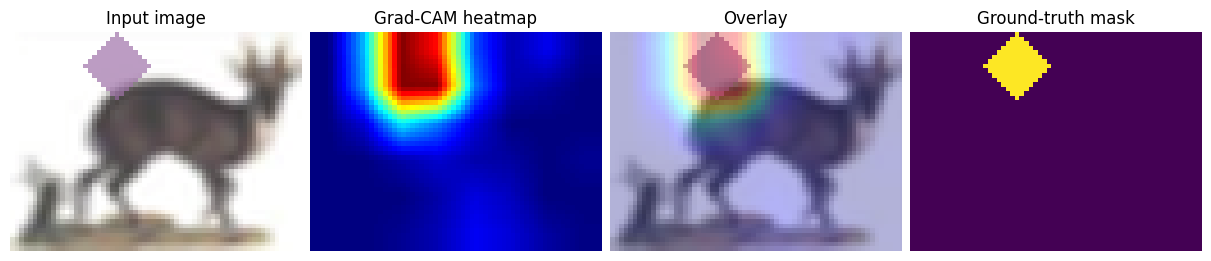

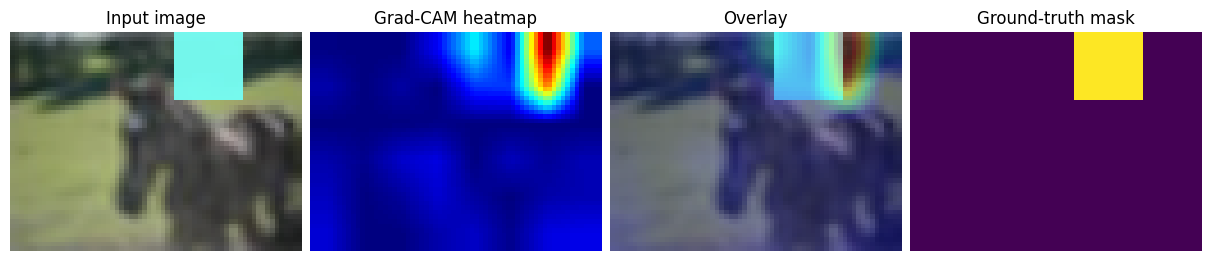

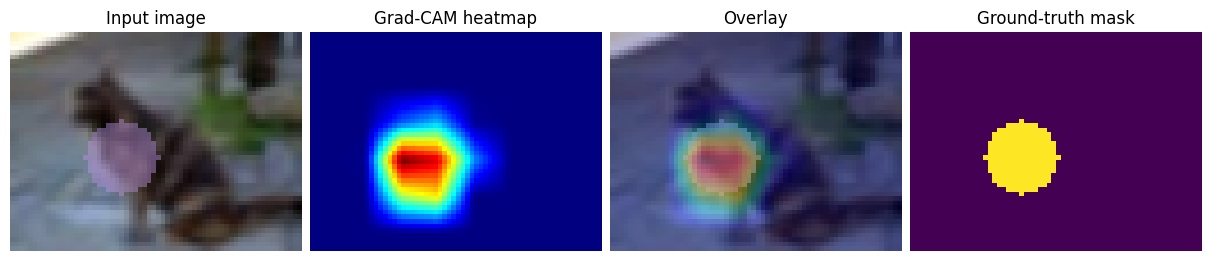

In [14]:
def example_gradcam():
    grad_cam = GradCAM(model=model, target_layers=target_layers)

    for test_idx in [3, 10, 42]:
        img, label, mask = test_dataset[test_idx]

        cam = grad_cam(img.unsqueeze(0).to(device), targets=[label])
        heatmap_img = heatmap_to_rgb_image(cam.squeeze(0), 0, 1)

        show_image_row(
            {
                "Input image": inverse_transform(img),
                "Grad-CAM heatmap": heatmap_img,
                "Overlay": PIL.Image.blend(inverse_transform(img), heatmap_img, alpha=0.3),
                "Ground-truth mask": mask,
            }
        )


example_gradcam()

# 2. Segment Anything Model



## Basic usage [do not modify]
The checkpoint takes 360 MB.

In [15]:
%pip install segment-anything
!wget -nc -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

In [16]:
from segment_anything import SamPredictor, sam_model_registry
from segment_anything.utils.transforms import ResizeLongestSide

sam_checkpoint_path = Path("./sam_vit_b_01ec64.pth")
assert sam_checkpoint_path.exists(), "SAM checkpoint not found."

# We'll use a single global SAM model to avoid reloading it to memory multiple times.
sam_model = sam_model_registry["vit_b"](checkpoint=sam_checkpoint_path)
sam_model.to(device)
sam_predictor = SamPredictor(sam_model)

In [17]:
class BasicSamPipeline:
    def __call__(self, images: Tensor) -> Tensor:
        """
        Input: normalized images, shape (B, C=3, H, W).
        Output: masks tensor of shape (B, H, W), dtype=bool.
        """
        B, C, H, W = images.shape
        # The basic pipeline always uses a single center point for each image.
        point_coords = np.array([[(W // 2, H // 2)] for _ in range(B)])

        # The basic pipeline always uses a single foreground point, no background points.
        point_labels = np.array([[1] for _ in range(B)], dtype=np.int64)

        return self.segment(images, point_coords, point_labels)

    def segment(
        self, images: Tensor, point_coords: np.ndarray, point_labels: np.ndarray
    ) -> Tensor:
        """
        Args:
        - images: normalized images, shape (B, C=3, H, W).
        - point_coords: point coordinates within each image, shape (B, num_points, 2), format (x,y).
            Note the format is not (h,w)=(y,x), but (x,y)!
        - point_labels: point labels, shape (B, num_points), dtype int64.
            Label 1 is foreground (should be in mask), 0 is background (shouldn't be in mask).

        Returns: segmentation masks, shape (B, H, W), dtype=bool.
        """
        B, C, H, W = images.shape
        assert C == 3, f"Expected images.shape=(B, C=3, H, W), got: {images.shape}"
        num_points = point_coords.shape[1]
        assert point_coords.shape == (B, num_points, 2), f"Expected point_coords.shape=({B=}, num_points, 2), got: {point_coords.shape}"
        assert point_labels.shape == (B, num_points), f"Expected point_labels.shape=({B=}, num_points), got: {point_labels.shape}"

        results = list[Tensor]()
        for image, pt_coords, pt_labels in zip(images, point_coords, point_labels, strict=True):
            sam_predictor.set_image(np.array(inverse_transform(image)))
            masks, scores, _logits = sam_predictor.predict(
                point_coords=pt_coords, point_labels=pt_labels, multimask_output=True
            )
            best_mask = masks[np.argmax(scores)]
            results.append(torch.tensor(best_mask, dtype=torch.bool))
        return torch.stack(results)

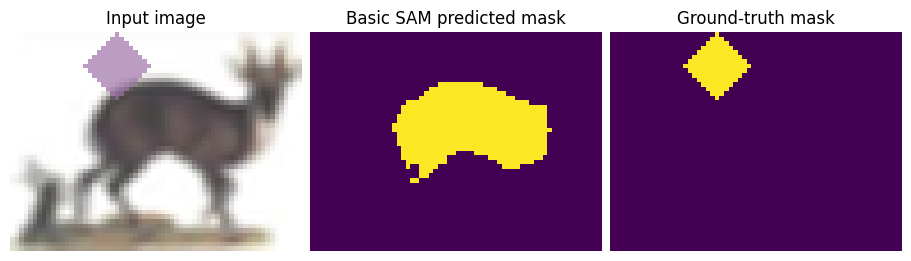

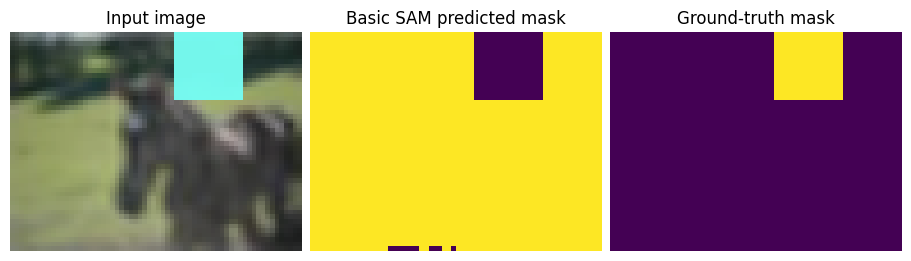

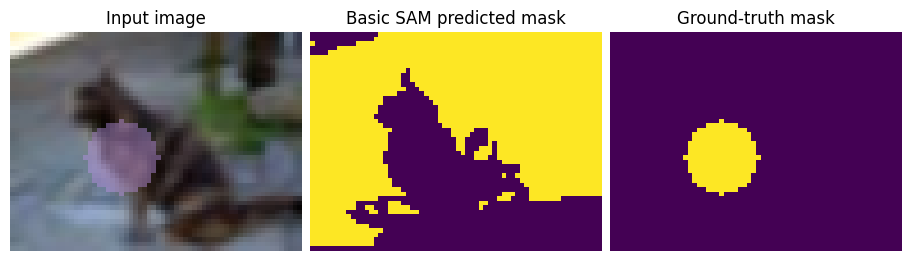

In [18]:
def example_sam():
    indices = [3, 10, 42]
    images, labels, gt_masks = next(iter(test_loader))
    images, labels, gt_masks = images[indices], labels[indices], gt_masks[indices]

    basic_pipeline = BasicSamPipeline()

    results = basic_pipeline(images).cpu()

    for image, result, gt_mask in zip(images, results, gt_masks, strict=True):
        show_image_row(
            {
                "Input image": inverse_transform(image),
                "Basic SAM predicted mask": result,
                "Ground-truth mask": gt_mask,
            }
        )


example_sam()

## Pipeline implementation and evaluation (add your code)

### Some utils

In [19]:
def restore_dims_from_flat(pts: Tensor, w):
    pts_x = pts % w
    pts_y = pts // w
    return torch.stack((pts_x, pts_y), dim=-1)

def get_coords_for_shape(batch_size, h, w):
    coords_y, coords_x = torch.meshgrid(torch.arange(h), torch.arange(w), indexing='ij')
    coords = torch.stack((coords_y, coords_x), dim=-1).unsqueeze(0).expand(batch_size, -1, -1, -1)
    return coords

def get_mass_centers(heat_maps: Tensor) -> Tensor:
    (batch_size, h, w) = heat_maps.shape
    grid_y, grid_x = torch.meshgrid(torch.arange(h), torch.arange(w), indexing='ij')
    grid_y = grid_y.unsqueeze(0)
    grid_x = grid_x.unsqueeze(0)

    all_heat = torch.sum(heat_maps.view(batch_size, -1), dim=-1) + 1e-9
    centers_y = torch.sum((heat_maps * grid_y).view(batch_size, -1), dim=-1) / all_heat
    centers_x = torch.sum((heat_maps * grid_x).view(batch_size, -1), dim=-1) / all_heat

    return torch.stack((centers_y, centers_x), dim=-1)

def get_max_heat_pixel(heat_maps: Tensor) -> Tensor:
    (batch_size, h, w) = heat_maps.shape
    max_indices = torch.argmax(heat_maps.view(batch_size, -1), dim=-1)
    centers_y = max_indices // w
    centers_x = max_indices % w
    return torch.stack((centers_y, centers_x), dim=-1)

def get_offsets(heat_maps: Tensor, gt_masks: Tensor, targets: Tensor):
    hm_centers = get_max_heat_pixel(heat_maps)
    gt_centers = get_mass_centers(gt_masks.to(torch.float32))

    offsets = gt_centers - hm_centers
    per_label_offsets = torch.zeros((len(SyntheticData.CLASSES), 2))
    per_label_offsets.index_add_(0, targets, offsets)
    counts = torch.bincount(targets, minlength=len(SyntheticData.CLASSES))

    return per_label_offsets, counts

def yx_to_xy(coords: Tensor):
    return coords.flip(-1)

In [20]:
def get_optimal_offsets(
    dataloader: DataLoader,
    grad_cam: GradCAM
):
    offsets = torch.zeros((len(SyntheticData.CLASSES), 2))
    counts = torch.zeros(len(SyntheticData.CLASSES))
    for images, labels, gt_masks in dataloader:
        heat_maps = Tensor(grad_cam(images))
        new_offsets, new_counts = get_offsets(
            heat_maps,
            gt_masks,
            labels
        )
        offsets += new_offsets
        counts += new_counts
    counts = counts.unsqueeze(-1)
    offsets_avg = yx_to_xy(offsets / (counts + 1e-9))
    result = offsets_avg.round().to(torch.long)
    return result

optimal_offsets = get_optimal_offsets(train_loader, GradCAM(model, target_layers))
print(SyntheticData.CLASSES)
print(optimal_offsets)

('circle', 'square', 'triangle', 'star', 'diamond')
tensor([[ 0, -1],
        [-2,  2],
        [-1,  5],
        [-2, -2],
        [-1, -1]])


### At least one foreground point, without background points

In [21]:
def get_foreground_pts(heat_maps: Tensor, n_pts, targets: Tensor, offsets: Tensor) -> Tensor:
    (batch_size, h, w) = heat_maps.shape
    heat_maps_flat = heat_maps.view(batch_size, -1)

    foreground_pts = torch.topk(heat_maps_flat, k=n_pts, dim=-1)[1]
    foreground_pts = restore_dims_from_flat(foreground_pts, w)

    batch_offsets = offsets[targets].unsqueeze(1)
    foreground_pts = foreground_pts + batch_offsets

    max_vals = torch.tensor([w-1, h-1], device=heat_maps.device)
    min_vals = torch.tensor(0, device=heat_maps.device)
    fg_pts_clamped = torch.clamp(foreground_pts, min=min_vals, max=max_vals)

    return fg_pts_clamped


class SamPipeline1(BasicSamPipeline):
    def __init__(
        self,
        grad_cam: GradCAM,
        offsets: Tensor,
        n_pts: int = 10
    ):
        self.grad_cam = grad_cam
        self.offsets = offsets
        self.n_pts = n_pts

    def __call__(self, images: Tensor) -> Tensor:
        heat_maps = self.grad_cam(images)
        (batch_size, _, h, w) = images.shape
        heat_maps = torch.tensor(heat_maps)

        foreground_pts = get_foreground_pts(
            heat_maps,
            self.n_pts,
            self.grad_cam.cache_targets.to(heat_maps.device),
            self.offsets.to(heat_maps.device)
        )
        foreground_pts = foreground_pts.detach().cpu().numpy()
        point_labels = np.ones((batch_size, self.n_pts), np.int64)

        return self.segment(images, foreground_pts, point_labels)

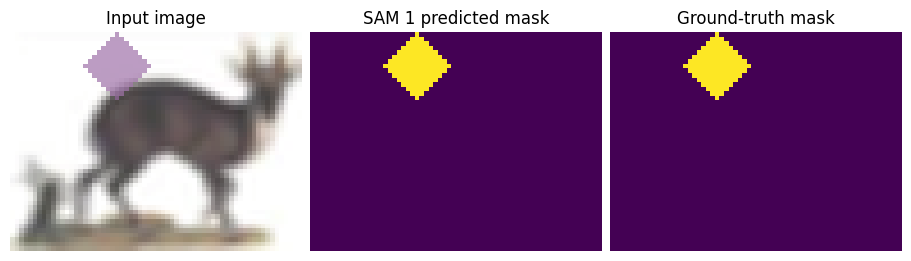

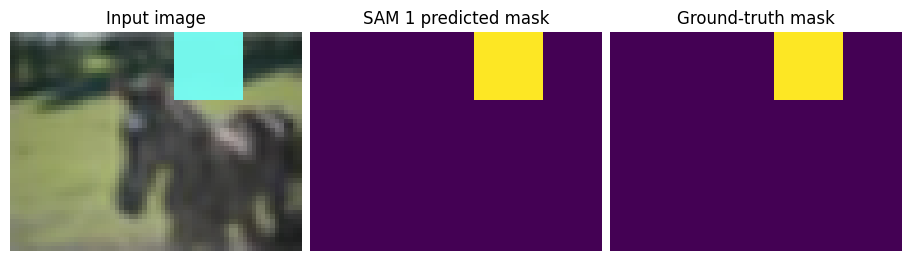

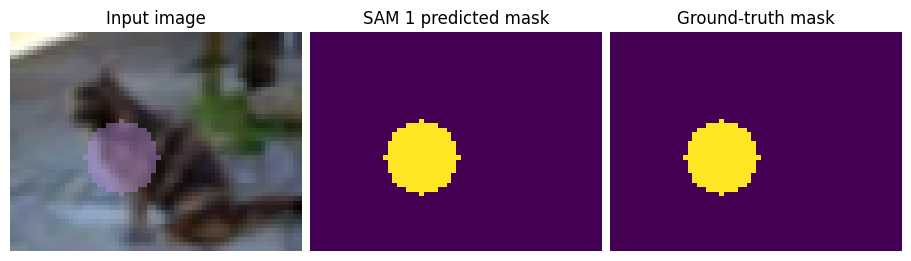

In [22]:
def sam_1(offset: Tensor):
    indices = [3, 10, 42]
    images, labels, gt_masks = next(iter(test_loader))
    images, labels, gt_masks = images[indices], labels[indices], gt_masks[indices]
    grad_cam = GradCAM(model=model, target_layers=target_layers)
    basic_pipeline = SamPipeline1(grad_cam, offset, 5)

    results = basic_pipeline(images).cpu()

    for image, result, gt_mask in zip(images, results, gt_masks, strict=True):
        show_image_row(
            {
                "Input image": inverse_transform(image),
                "SAM 1 predicted mask": result,
                "Ground-truth mask": gt_mask,
            }
        )


sam_1(optimal_offsets)

### At least one foreground point and at least one background point.

In [23]:
def get_background_pts(heat_maps: Tensor, n_pts) -> Tensor:
    (batch_size, h, w) = heat_maps.shape

    nth_smallest, _ = torch.topk(heat_maps.view(batch_size, -1), k=n_pts, largest=False)
    nth_smallest = nth_smallest[:, -1, None, None]
    fg_pts = heat_maps > nth_smallest + 1e-3

    coords = get_coords_for_shape(batch_size, h, w)
    centers = get_mass_centers(heat_maps)
    centers = centers.unsqueeze(1).unsqueeze(1)

    distances = torch.sum((coords - centers) ** 2, dim=-1)
    distances = distances + fg_pts * 1e9

    indices = torch.topk(distances.view(batch_size, -1), k=n_pts, dim=-1, largest=False)[1]

    return restore_dims_from_flat(indices, w)


class SamPipeline2(BasicSamPipeline):
    def __init__(
        self,
        grad_cam: GradCAM,
        offsets: Tensor,
        n_pts_fg: int = 10,
        n_pts_bg: int = 10,
    ):
        self.grad_cam = grad_cam
        self.offsets = offsets
        self.n_pts_fg = n_pts_fg
        self.n_pts_bg = n_pts_bg

    def __call__(self, images: Tensor) -> Tensor:
        heat_maps = self.grad_cam(images)
        (batch_size, _, h, w) = images.shape
        heat_maps = torch.tensor(heat_maps)
        foreground_pts = get_foreground_pts(
            heat_maps,
            self.n_pts_fg,
            self.grad_cam.cache_targets.to(heat_maps.device),
            self.offsets.to(heat_maps.device)
        )
        background_pts = get_background_pts(heat_maps, self.n_pts_bg)

        point_labels = torch.cat([
            torch.ones((batch_size, self.n_pts_fg), dtype=torch.int64),
            torch.zeros((batch_size, self.n_pts_bg), dtype=torch.int64)
        ], dim=1
        )
        pts = torch.cat([foreground_pts, background_pts], dim=1)

        point_labels = point_labels.detach().cpu().numpy()
        pts = pts.detach().cpu().numpy()

        return self.segment(images, pts, point_labels)

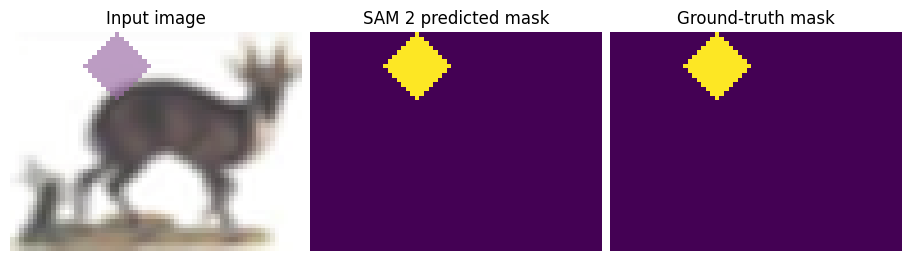

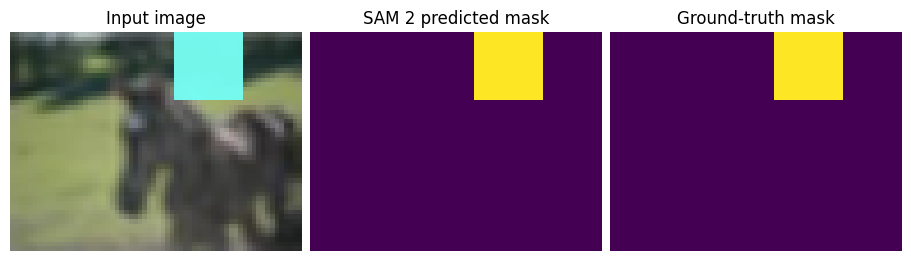

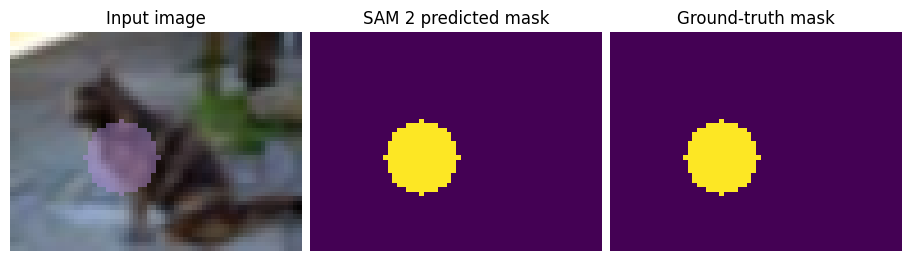

In [24]:
def sam_2(offsets: Tensor):
    indices = [3, 10, 42]
    images, labels, gt_masks = next(iter(test_loader))
    images, labels, gt_masks = images[indices], labels[indices], gt_masks[indices]
    grad_cam = GradCAM(model=model, target_layers=target_layers)
    basic_pipeline = SamPipeline2(grad_cam, offsets, 5, 5)

    results = basic_pipeline(images).cpu()

    for image, result, gt_mask in zip(images, results, gt_masks, strict=True):
        show_image_row(
            {
                "Input image": inverse_transform(image),
                "SAM 2 predicted mask": result,
                "Ground-truth mask": gt_mask,
            }
        )


sam_2(optimal_offsets)

## Evaluation

#### Hit rate

In [25]:
def get_hit_rate_batch(
    images: Tensor,
    labels: Tensor,
    gt_masks: Tensor,
    grad_cam: GradCAM,
    n_pts: int,
    offsets:Tensor
):
    heat_maps = grad_cam(images, labels)
    heat_maps = torch.tensor(heat_maps)
    points = get_foreground_pts(
        heat_maps,
        n_pts,
        grad_cam.cache_targets,
        offsets
    )
    i_s = torch.arange(
        0, points.size(0),
        dtype=torch.long
    ).unsqueeze(0).expand(points.size(1), -1).T.reshape(-1)
    x_s = points[:, :, 0].reshape(-1)
    y_s = points[:, :, 1].reshape(-1)
    return torch.sum(gt_masks[i_s, y_s, x_s]), len(i_s)


def get_hit_rate(
    dataloader: DataLoader,
    grad_cam: GradCAM,
    n_pts: int,
    offsets:Tensor
):
    hits = 0
    shots = 0
    for images, labels, gt_masks in dataloader:
        new_hits, new_shots = get_hit_rate_batch(
            images,
            labels,
            gt_masks,
            grad_cam,
            n_pts,
            offsets
        )
        hits += new_hits
        shots += new_shots
    return hits / (shots + 1e-9)

#### Distance

In [26]:
def get_distance_batch(
    images: Tensor,
    labels: Tensor,
    gt_masks: Tensor,
    grad_cam: GradCAM,
    n_pts: int,
    offsets:Tensor
):
    heat_maps = grad_cam(images, labels)
    heat_maps = torch.tensor(heat_maps)

    points = get_foreground_pts(
        heat_maps,
        n_pts,
        grad_cam.cache_targets,
        offsets
    )
    centers = get_mass_centers(gt_masks)

    centers = centers.unsqueeze(1)
    distances = torch.sum(
        torch.sqrt(
            torch.sum(
                (points - centers) ** 2,
                dim=-1
            )
        )
    )

    return distances, points.numel() // 2

def get_distance(
    dataloader: DataLoader,
    grad_cam: GradCAM,
    n_pts: int,
    offset: Tensor
):
    distance = 0
    n = 0
    for images, labels, gt_masks in dataloader:
        new_dist, new_n = get_distance_batch(
            images,
            labels,
            gt_masks,
            grad_cam,
            n_pts,
            offset
        )
        distance += new_dist
        n += new_n
    return distance / n



#### IoU

In [27]:
def get_iou_batch(
    images: Tensor,
    gt_masks: Tensor,
    sam: BasicSamPipeline
):
    batch_size = images.size(0)

    sam_result = sam(images)
    intersection = torch.sum(
        torch.logical_and(sam_result, gt_masks).reshape(batch_size, -1),
        dim=-1
    )
    union = torch.sum(
        torch.logical_or(sam_result, gt_masks).reshape(batch_size, -1),
        dim=-1
    )

    iou_sum = torch.sum(intersection / (union + 1e-9))
    return iou_sum, batch_size

def get_iou(
    dataloader: DataLoader,
    sam: BasicSamPipeline
):
    iou_sum = 0
    n = 0
    for images, _, gt_masks in dataloader:
        new_iou, new_n = get_iou_batch(
            images,
            gt_masks,
            sam
        )
        iou_sum += new_iou
        n += new_n
    return iou_sum / n

### I will find the optimal number of points for grad cam

In [28]:
!pip install plotly

In [29]:
import pandas as pd
import plotly.express as px

grad_cam = GradCAM(model=model, target_layers=target_layers)

ns = [1, 2, 3, 4, 5, 10, 15, 20, 25]

results = {
    "n_fg_pts": ns,
    "hit_rate_no_off": [],
    "distance_no_off": [],
    "hit_rate_off": [],
    "distance_off": []
}

no_offset = torch.zeros(
    (len(SyntheticData.CLASSES), 2),
    dtype=torch.long
)

for n_fg_pts in ns:
    results["hit_rate_no_off"].append(
        get_hit_rate(
            val_loader, grad_cam, n_fg_pts, no_offset
        )
    )
    results["hit_rate_off"].append(
        get_hit_rate(
            val_loader, grad_cam, n_fg_pts, optimal_offsets
        )
    )
    results["distance_no_off"].append(
        get_distance(
            val_loader, grad_cam, n_fg_pts, no_offset
    ))
    results["distance_off"].append(
        get_distance(
            val_loader, grad_cam, n_fg_pts, optimal_offsets
    ))
df = pd.DataFrame(results)
fig1 = px.line(
    df,
    width=800,
    x="n_fg_pts",
    y=["distance_no_off", "distance_off"],
    title="Average distance to mass center of selected foreground points",
)
fig1.show()
fig2 = px.line(
    df,
    width=800,
    x="n_fg_pts",
    y=["hit_rate_no_off", "hit_rate_off"],
    title="Hit rate of selected foreground points",
)
fig2.show()

In [30]:
from torch.utils.data import Subset

results_class = {
    "n_fg_pts": [],
    "hit_rate_no_off": [],
    "distance_no_off": [],
    "hit_rate_off": [],
    "distance_off": [],
    "class": []
}

class_indices = {i: [] for i in range(len(SyntheticData.CLASSES))}
for idx in range(len(val_dataset)):
    _, label, _ = val_dataset[idx]
    class_indices[label].append(idx)

for class_idx, indices in class_indices.items():
    class_name = SyntheticData.CLASSES[class_idx]
    class_subset = Subset(val_dataset, indices)
    class_loader = DataLoader(class_subset, batch_size=500, num_workers=2, pin_memory=use_accel)

    for n_fg_pts in ns:
        results_class["hit_rate_no_off"].append(
            get_hit_rate(
                class_loader, grad_cam, n_fg_pts, no_offset
                )
        )
        results_class["distance_no_off"].append(
            get_distance(
            class_loader, grad_cam, n_fg_pts, no_offset
            )
        )
        results_class["hit_rate_off"].append(
            get_hit_rate(
                class_loader, grad_cam, n_fg_pts, optimal_offsets
            )
        )
        results_class["distance_off"].append(
            get_distance(
                class_loader, grad_cam, n_fg_pts, optimal_offsets
            )
        )
        results_class["class"].append(class_name)
        results_class["n_fg_pts"].append(n_fg_pts)

df_class = pd.DataFrame(results_class)

fig_dist_class = px.line(
    df_class,
    width=800,
    x="n_fg_pts",
    y=["distance_off"],
    color="class",
    title="Average distance to mass center of selected foreground points (per class)",
)
fig_dist_class.show()

fig_hr_class = px.line(
    df_class,
    width=800,
    x="n_fg_pts",
    y=["hit_rate_off"],
    color="class",
    title="Hit rate of selected foreground points (per class)",
)
fig_hr_class.show()

#### Results

Add any necessary cells regarding pipeline and evaluation.

In [31]:
sam_eval_loader = DataLoader(test_dataset, batch_size=5, num_workers=0, pin_memory=use_accel)

grad_cam = GradCAM(model=model, target_layers=target_layers)
sam1 = SamPipeline1(grad_cam, optimal_offsets, 5)
sam2 = SamPipeline2(grad_cam, optimal_offsets,  5, 5)


iou_sam1 = get_iou(sam_eval_loader, sam1)
iou_sam2 = get_iou(sam_eval_loader, sam2)

print("iou_sam1:", iou_sam1)
print("iou_sam2:", iou_sam2)

iou_sam1: tensor(0.8058)
iou_sam2: tensor(0.7849)
